In [1]:
from aoespy import *
import xarray as xr
dir='/nobackupp27/afahad/exp/'
data='/nobackupp27/afahad/exp/script_replay_AGU/data/'

/home6/afahad/.local/lib/python3.9/site-packages/aoespy.py:19: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [38]:
rp=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_RP0506/holding/geosgcm_prog/200505/*geosgcm_prog.*200505*z.nc4')
me=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_ME0506/holding/geosgcm_prog/200505/*geosgcm_prog.*200505*z.nc4')

In [3]:
rp1=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_RP0506/holding/geosgcm_prog/200506/*geosgcm_prog.*200506*z.nc4')
me1=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_ME0506/holding/geosgcm_prog/200506/*geosgcm_prog.*200506*z.nc4')

In [39]:
rp=xr.concat((rp,rp1),dim='time')
me=xr.concat((me,me1),dim='time')

In [40]:
rp=rp[['T','SLP','RH', 'U']].compute()
me=me[['T','SLP','RH', 'U']].compute()

In [41]:
rp=rp.sel(lev=slice(1000,500))
me=me.sel(lev=slice(1000,500))

In [42]:
rpP = rp.lev  # hPa
rpP0 = rp.SLP  # hPa
rpT = rp.T  # K
rpR = rp.RH
rpU = rp.U  # K

meP = me.lev  # hPa
meT = me.T  # K
meP0 = me.SLP  # hPa
meR = me.RH
meU = me.U  # K

In [43]:
def calculate_vapor_pressure(T, RH):
  """
  Calculates the vapor pressure in hPa.

  Args:
    T: Temperature in Celsius.
    RH: Relative humidity in percent.

  Returns:
    Vapor pressure in hPa.
  """
  # Calculate saturation vapor pressure (es) using the Magnus formula
  es = 6.112 * exp((17.67 * T) / (T + 243.5))

  # Calculate vapor pressure (e)
  e = (RH / 100) * es
  return e

# Function to calculate dew point temperature (Td) from vapor pressure (e)
def calculate_dew_point(e):
  """
  Calculates the dew point temperature in Celsius.

  Args:
    e: Vapor pressure in hPa.

  Returns:
    Dew point temperature in Celsius.
  """
  # Calculate dew point temperature (Td) using the inverse Magnus formula
  Td = (243.5 * log(e / 6.112)) / (17.67 - log(e / 6.112))
  return Td

In [44]:
# rpTd=calculate_dew_point(calculate_vapor_pressure(rpT-273.15, rpR))

In [45]:
# meTd=calculate_dew_point(calculate_vapor_pressure(meT-273.15, meR))

In [46]:
R = 287  # Gas constant for dry air (J/(kg*K))
Cp = 1004  # Specific heat capacity of dry air at constant pressure (J/(kg*K))

In [47]:
rpPt=rpT * (rpP0 / rpP)**(R / Cp)

In [48]:
mePt=meT * (meP0 / meP)**(R / Cp)

In [81]:
rpUs=rpU.sel(lev=500)-rpU.sel(lev=1000)
meUs=meU.sel(lev=500)-meU.sel(lev=1000)


In [82]:
rpTheta=rpPt.sel(lev=500)-rpPt.sel(lev=1000)
meTheta=mePt.sel(lev=500)-mePt.sel(lev=1000)


In [ ]:
rpP0=rpP0.resample(time='1D').mean()
meP0=meP0.resample(time='1D').mean()


# rpTheta=rpTheta.rolling(time=2, center=True).mean()
# meTheta=meTheta.rolling(time=2, center=True).mean()

In [ ]:
plt.figure(figsize=(12, 6))



x1=-178
x2=-178
y1=2
y2=2

x1=143
x2=143
y1=-1
y2=-1

x1=-127
x2=-127
y1=7
y2=7

# Plot potential temperature vs. pressure
plt.plot(rpTheta.time,rpP0.sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),  color='orange')
         
plt.plot(meTheta.time,meP0.sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),  color='blue')

#plt.gca().invert_yaxis()  # Invert y-axis to show pressure decreasing upwards
# plt.xlabel("Potential Temperature (K)")
# plt.ylabel("Pressure (hPa)")
plt.title("Atmospheric Stability at a Specific Time and Location")


Text(0.5, 1.0, 'Atmospheric Stability at a Specific Time and Location')

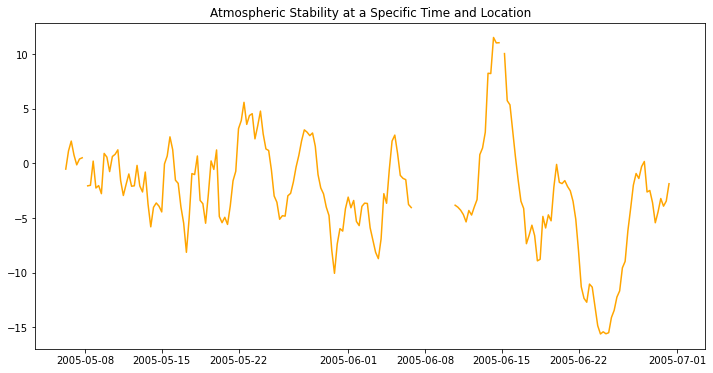

In [85]:
plt.figure(figsize=(12, 6))









x1=-178
x2=-178
y1=2
y2=2


x1=143
x2=143
y1=-1
y2=-1


x1=-127
x2=-127
y1=7
y2=7

# Plot potential temperature vs. pressure
plt.plot(rpUs.time,(meUs-rpUs).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),  color='orange')
#plt.plot(meUs.time,meUs.sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),  color='blue')

#plt.gca().invert_yaxis()  # Invert y-axis to show pressure decreasing upwards
# plt.xlabel("Potential Temperature (K)")
# plt.ylabel("Pressure (hPa)")
plt.title("Atmospheric Stability at a Specific Time and Location")


In [103]:
rpN2=N2(rpT.sel(time='2005-06-08T00:00:00.000000000'), rpP0.sel(time='2005-06-08T00:00:00.000000000').data,rpP.data,rp.lon.data,rp.lat.data)

  0%|          | 0/48 [00:00<?, ?it/s]

In [136]:
meN2=N2(meT.sel(time='2005-06-08T00:00:00.000000000'), meP0.sel(time='2005-06-08T00:00:00.000000000').data,meP.data,rp.lon.data,rp.lat.data)

  0%|          | 0/13 [00:00<?, ?it/s]

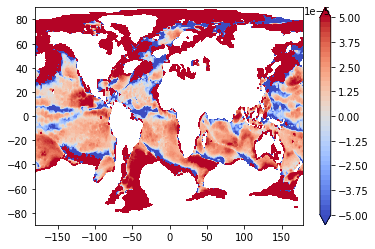

In [119]:
plt.contourf(rpT.lon,rpT.lat,rpN2[0][0,:,:],levels=arange(-.05,.051,.0025)*1e-3,cmap='coolwarm',extend='both')
plt.colorbar()

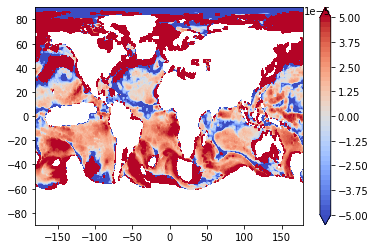

In [137]:
plt.contourf(rpT.lon,rpT.lat,meN2[0][0,:,:],levels=arange(-.05,.051,.0025)*1e-3,cmap='coolwarm',extend='both')
plt.colorbar()

In [140]:
# ME506=ME506
# RP506=RP506.sel(time=slice('2005-06-04','2005-06-15'))

In [141]:
# clf=arange(-2,2.1,.1)
# f()
# plt.subplot(2,1,1)
# ME506.sel(lat=slice(30,35)).mean(dim='lat').plot(levels=clf,cmap='coolwarm')
# plt.subplot(2,1,2)
# RP506.sel(lat=slice(30,35)).mean(dim='lat').plot(levels=clf,cmap='coolwarm')

In [142]:
# clf=arange(-2,2.1,.1)
# f()
# plt.subplot(2,1,1)
# plt.contourf(ME506.lon,ME506.time,ME506.sel(lat=slice(3,5)).mean(dim='lat'),levels=clf,cmap='coolwarm')
# plt.colorbar()
# plt.subplot(2,1,2)
# plt.contourf(ME506.lon,ME506.time,(ME506-RP506).sel(lat=slice(3,5)).mean(dim='lat'),levels=clf,cmap='coolwarm')
# plt.colorbar()

In [143]:
# rp=rp.resample(time='1D').mean()
# me=me.resample(time='1D').mean()

In [144]:
# RP506.data[RP506.data>0]=0
# ME506.data[ME506.data>0]=0

In [145]:
# for j in range(180):
#     for i in range(360):
# #         if nanmax(ME426P[:,j,i])>100:
#             if nanmax(abs(ME506[:,j,i]))>2:
# #                 if nanmax(ME511P[:,j,i])>100:
# #                             if nanmax(RP426P[:,j,i])<50:
#                                 if nanmax(abs(RP506[:,j,i]))<2:
# #                                     if nanmax(RP511P[:,j,i])<50:
#                                         print(ME506.lat[j].data,ME506.lon[i].data,j,i)

In [146]:
ticks=[]

for i in range(len(ME506.time)):
    ticks=append(ticks,str(ME506.time.data[i])[5:10])

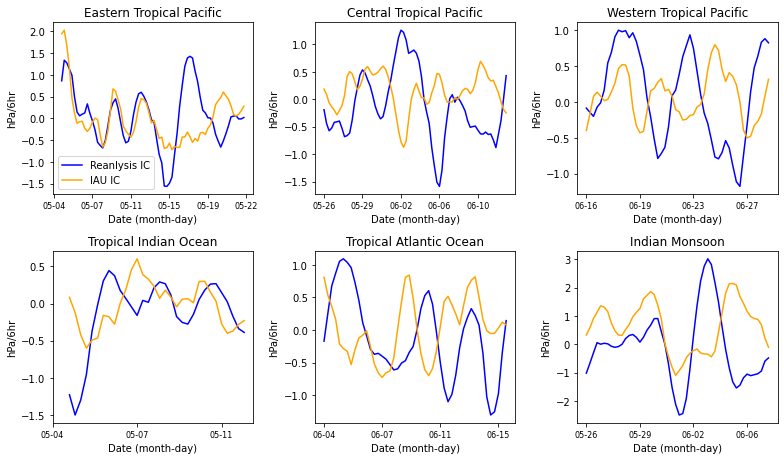

In [148]:

x1=-127
x2=-127
y1=7
y2=7

# x1=-116
# x2=-115
# y1=5
# y2=5

plt.figure(figsize=(11,6.5))


plt.subplot(2,3,1)

ticks=[]
dd=pd.date_range(start='2005-05-04', end='2005-05-23',freq='6H')

for i in range(len(dd)):
    ticks=append(ticks,str(dd[i])[5:10])
    
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506.sel(time=slice('2005-05-06','2005-05-25'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506.sel(time=slice('2005-05-06','2005-05-25'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Eastern Tropical Pacific')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.legend(['Reanlysis IC', 'IAU IC'])
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')


x1=-178
x2=-178
y1=2
y2=2

plt.subplot(2,3,2)
ticks=[]

for i in range(len(ME506.sel(time=slice('2005-05-26','2005-06-12')).time)):
    ticks=append(ticks,str(ME506.sel(time=slice('2005-05-26','2005-06-12')).time.data[i])[5:10])

# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506.sel(time=slice('2005-05-28','2005-06-14'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506.sel(time=slice('2005-05-28','2005-06-14'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Central Tropical Pacific')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')




ticks=[]

for i in range(len(ME506.sel(time=slice('2005-06-16','2005-06-28')).time)):
    ticks=append(ticks,str(ME506.sel(time=slice('2005-06-16','2005-06-28')).time.data[i])[5:10])

    
plt.subplot(2,3,3)

x1=143
x2=143
y1=-1
y2=-1

plt.plot((ME506.sel(time=slice('2005-06-18','2005-06-30'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot((RP506.sel(time=slice('2005-06-18','2005-06-30'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')


plt.title('Western Tropical Pacific')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')

x1=89
x2=92
y1=7
y2=8



ticks=[]
dd=pd.date_range(start='2005-05-04', end='2005-05-13',freq='6H')

for i in range(len(dd)):
    ticks=append(ticks,str(dd[i])[5:10])
    
plt.subplot(2,3,4)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506.sel(time=slice('2005-05-06','2005-05-15'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506.sel(time=slice('2005-05-06','2005-05-15'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Indian Ocean')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')

x1=-39
x2=-38
y1=7
y2=8


ticks=[]

for i in range(len(ME506.sel(time=slice('2005-06-04','2005-06-15')).time)):
    ticks=append(ticks,str(ME506.sel(time=slice('2005-06-04','2005-06-15')).time.data[i])[5:10])

    

plt.subplot(2,3,5)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506.sel(time=slice('2005-06-06','2005-06-17'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506.sel(time=slice('2005-06-06','2005-06-17'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Atlantic Ocean')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')

x1=90
x2=91
y1=23
y2=25


ticks=[]

for i in range(len(ME506.sel(time=slice('2005-05-26','2005-06-07')).time)):
    ticks=append(ticks,str(ME506.sel(time=slice('2005-05-26','2005-06-07')).time.data[i])[5:10])

    
plt.subplot(2,3,6)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506.sel(time=slice('2005-05-28','2005-06-9'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506.sel(time=slice('2005-05-28','2005-06-9'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Indian Monsoon')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')


plt.tight_layout()
plt.savefig('spike_dpsdt.png',dpi=150)

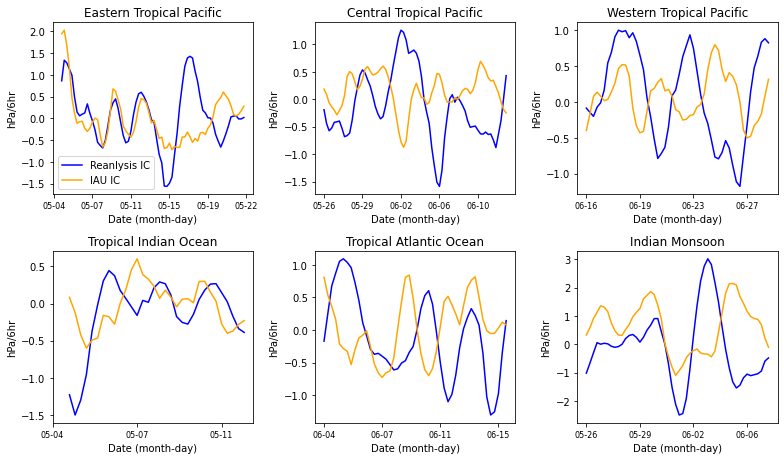

In [130]:

x1=-127
x2=-127
y1=7
y2=7

# x1=-116
# x2=-115
# y1=5
# y2=5

plt.figure(figsize=(11,6.5))


plt.subplot(2,3,1)

ticks=[]
dd=pd.date_range(start='2005-05-04', end='2005-05-23',freq='6H')

for i in range(len(dd)):
    ticks=append(ticks,str(dd[i])[5:10])
    
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506.sel(time=slice('2005-05-06','2005-05-25'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506.sel(time=slice('2005-05-06','2005-05-25'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Eastern Tropical Pacific')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.legend(['Reanlysis IC', 'IAU IC'])
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')


x1=-178
x2=-178
y1=2
y2=2

plt.subplot(2,3,2)
ticks=[]

for i in range(len(ME506.sel(time=slice('2005-05-26','2005-06-12')).time)):
    ticks=append(ticks,str(ME506.sel(time=slice('2005-05-26','2005-06-12')).time.data[i])[5:10])

# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506.sel(time=slice('2005-05-28','2005-06-14'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506.sel(time=slice('2005-05-28','2005-06-14'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Central Tropical Pacific')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')




ticks=[]

for i in range(len(ME506.sel(time=slice('2005-06-16','2005-06-28')).time)):
    ticks=append(ticks,str(ME506.sel(time=slice('2005-06-16','2005-06-28')).time.data[i])[5:10])

    
plt.subplot(2,3,3)

x1=143
x2=143
y1=-1
y2=-1

plt.plot((ME506.sel(time=slice('2005-06-18','2005-06-30'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot((RP506.sel(time=slice('2005-06-18','2005-06-30'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')


plt.title('Western Tropical Pacific')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')

x1=89
x2=92
y1=7
y2=8



ticks=[]
dd=pd.date_range(start='2005-05-04', end='2005-05-13',freq='6H')

for i in range(len(dd)):
    ticks=append(ticks,str(dd[i])[5:10])
    
plt.subplot(2,3,4)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506.sel(time=slice('2005-05-06','2005-05-15'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506.sel(time=slice('2005-05-06','2005-05-15'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Indian Ocean')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')

x1=-39
x2=-38
y1=7
y2=8


ticks=[]

for i in range(len(ME506.sel(time=slice('2005-06-04','2005-06-15')).time)):
    ticks=append(ticks,str(ME506.sel(time=slice('2005-06-04','2005-06-15')).time.data[i])[5:10])

    

plt.subplot(2,3,5)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506.sel(time=slice('2005-06-06','2005-06-17'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506.sel(time=slice('2005-06-06','2005-06-17'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Atlantic Ocean')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')

x1=90
x2=91
y1=23
y2=25


ticks=[]

for i in range(len(ME506.sel(time=slice('2005-05-26','2005-06-07')).time)):
    ticks=append(ticks,str(ME506.sel(time=slice('2005-05-26','2005-06-07')).time.data[i])[5:10])

    
plt.subplot(2,3,6)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506.sel(time=slice('2005-05-28','2005-06-9'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506.sel(time=slice('2005-05-28','2005-06-9'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Indian Monsoon')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')


plt.tight_layout()
#plt.savefig('spike_dpsdt.png',dpi=150)

In [131]:
import pandas as pd


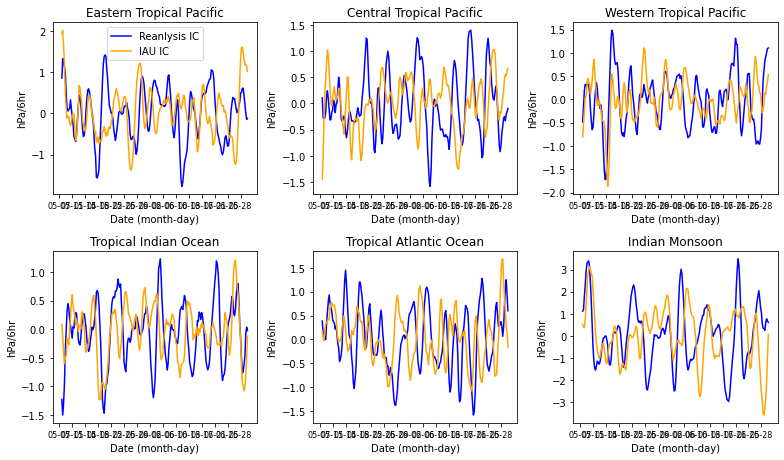

In [132]:

  
ticks=[]

for i in range(len(ME506.time)):
    ticks=append(ticks,str(ME506.time.data[i])[5:10])

x1=-127
x2=-127
y1=7
y2=7

# x1=-116
# x2=-115
# y1=5
# y2=5

plt.figure(figsize=(11,6.5))


plt.subplot(2,3,1)

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Eastern Tropical Pacific')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.legend(['Reanlysis IC', 'IAU IC'])
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')


x1=-178
x2=-178
y1=2
y2=2

plt.subplot(2,3,2)

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Central Tropical Pacific')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')

x1=136
x2=137
y1=3
y2=5


plt.subplot(2,3,3)

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')


plt.title('Western Tropical Pacific')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')

x1=89
x2=92
y1=7
y2=8


plt.subplot(2,3,4)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Indian Ocean')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')

x1=-39
x2=-38
y1=7
y2=8



plt.subplot(2,3,5)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Atlantic Ocean')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')

x1=90
x2=91
y1=23
y2=25



plt.subplot(2,3,6)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Indian Monsoon')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')


plt.tight_layout()
plt.savefig('spike_dpsdt_full.png',dpi=150)

In [506]:
# for i in range(len(ME506.lat)):
#     for j in range(len(ME506.lon)):
#         if nanmax( vbnME506[:,i,j]

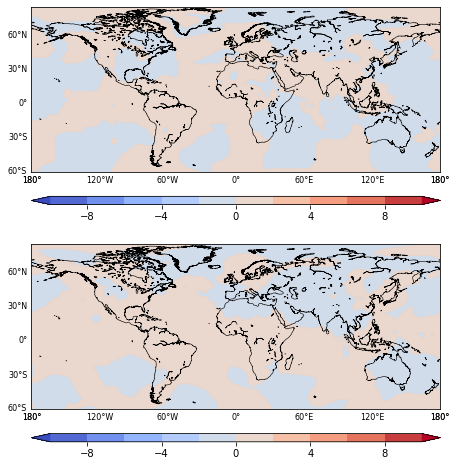

In [463]:
plt.figure(figsize=(8,8))
t=-1
plt.subplot(2,1,1)
plot(ME506[t,:,:]/100,lon1=-180,lon2=180,lat1=-60,lat2=85,clf=arange(-10,11,2));
plt.subplot(2,1,2)
plot((RP506[t,:,:]/100),clf=arange(-10,11,2),lon1=-180,lon2=180,lat1=-60,lat2=85);

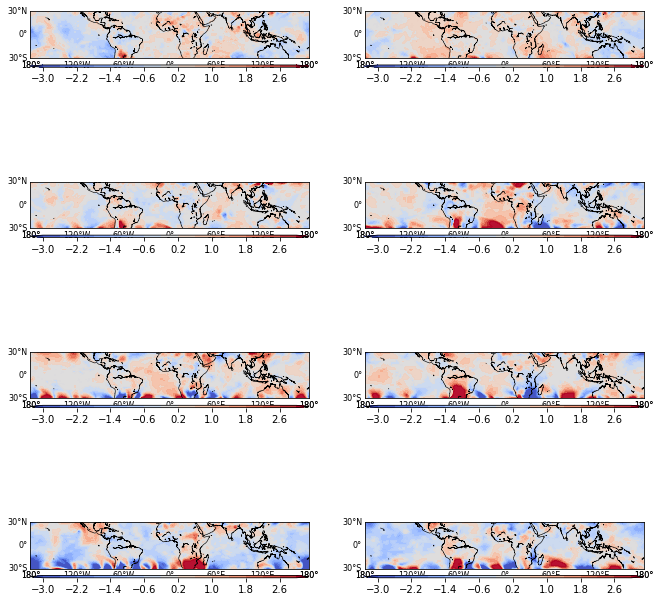

In [210]:
plt.figure(figsize=(11,12))

t=0
plt.subplot(4,2,1)
plot(abs(ME506[t,:,:]/100)-abs(RP506[t,:,:]/100),clf=arange(-3,3.1,.4),lon1=-180,lon2=180,lat1=-30,lat2=30);

t=2
plt.subplot(4,2,2)
plot(abs(ME506[t,:,:]/100)-abs(RP506[t,:,:]/100),clf=arange(-3,3.1,.4),lon1=-180,lon2=180,lat1=-30,lat2=30);

t=4
plt.subplot(4,2,3)
plot(abs(ME506[t,:,:]/100)-abs(RP506[t,:,:]/100),clf=arange(-3,3.1,.4),lon1=-180,lon2=180,lat1=-30,lat2=30);

t=24
plt.subplot(4,2,4)
plot(abs(ME506[t,:,:]/100)-abs(RP506[t,:,:]/100),clf=arange(-3,3.1,.4),lon1=-180,lon2=180,lat1=-30,lat2=30);


t=30
plt.subplot(4,2,5)
plot(abs(ME506[t,:,:]/100)-abs(RP506[t,:,:]/100),clf=arange(-3,3.1,.4),lon1=-180,lon2=180,lat1=-30,lat2=30);


t=33
plt.subplot(4,2,6)
plot(abs(ME506[t,:,:]/100)-abs(RP506[t,:,:]/100),clf=arange(-3,3.1,.4),lon1=-180,lon2=180,lat1=-30,lat2=30);

t=50
plt.subplot(4,2,7)
plot(abs(ME506[t,:,:]/100)-abs(RP506[t,:,:]/100),clf=arange(-3,3.1,.4),lon1=-180,lon2=180,lat1=-30,lat2=30);

t=-1
plt.subplot(4,2,8)
plot(abs(ME506[t,:,:]/100)-abs(RP506[t,:,:]/100),clf=arange(-3,3.1,.4),lon1=-180,lon2=180,lat1=-30,lat2=30);